# Task 3 — Forecast Future Market Trends

**Objective:** Using the best-performing model from Task 2 to forecast Tesla's stock price 6–12 months into the future, visualize forecasts with confidence intervals, and provide business insights on market opportunities and risks.


In [2]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data_loader import fetch_stock_data, extract_close_prices, clean_data
from src.train_test_split import chronological_split
from src.models.arima_model import find_best_arima_order, forecast_arima
from src.models.lstm_model import (
    scale_data, create_sequences, build_lstm_model,
    train_lstm, forecast_lstm
)

print("All imports loaded successfully.")


All imports loaded successfully.


## 1. Load and Prepare Data

In [3]:
# ── Download Tesla stock data ──
tickers = ["TSLA"]
raw_data = fetch_stock_data(tickers, start_date="2015-01-01", end_date="2026-06-30")

# ── Extract the Close price column for Tesla ──
close_prices = extract_close_prices(raw_data, tickers)
tsla_close = close_prices["TSLA"]

# ── Clean the data (fill any missing values) ──
tsla_close = clean_data(tsla_close.to_frame())["TSLA"]

print(f"Data shape: {tsla_close.shape}")
print(f"Date range: {tsla_close.index.min().date()} to {tsla_close.index.max().date()}")
tsla_close.tail()

[*********************100%***********************]  1 of 1 completed

[INFO] Downloaded data shape: (2888, 5)
[INFO] Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
[INFO] Missing values — before: 0, after: 0
Data shape: (2888,)
Date range: 2015-01-02 to 2026-06-29


Date
2026-06-23    381.609985
2026-06-24    375.529999
2026-06-25    375.119995
2026-06-26    379.709991
2026-06-29    411.839996
Name: TSLA, dtype: float64

In [4]:
# ── Split: everything before 2025 = training, 2025 onwards = test ──
train, test = chronological_split(tsla_close, split_date="2025-01-01")

print(f"\nTraining data: {len(train)} days")
print(f"Test data:     {len(test)} days")

[INFO] Train period: 2015-01-02 00:00:00 → 2024-12-31 00:00:00
[INFO] Train size:   2516 days
[INFO] Test period:  2025-01-02 00:00:00 → 2026-06-29 00:00:00
[INFO] Test size:    372 days

Training data: 2516 days
Test data:     372 days


## 2. Retrain the Best Model (ARIMA)

Based on Task 2 results, I use the ARIMA model for future forecasting because:
- It provides **built-in confidence intervals** (LSTM does not)
- It is better suited for generating uncertainty bounds
- It is more interpretable for business insights

In [5]:
# ── Use auto_arima to find the best (p, d, q) parameters ──
best_model = find_best_arima_order(train, seasonal=False)

# ── Save the order for reference ──
best_order = best_model.order
print(f"\n Best ARIMA order: {best_order}")


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.64 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.40 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.57 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.235 seconds

[INFO] Best order found: (0, 1, 0)
[INFO] AIC: 16368.11

 Best ARIMA order: (0, 1, 0)


In [6]:
# ── Forecast on the test period to see how good the model is ──
test_forecast, test_conf_int = forecast_arima(best_model, steps=len(test), is_pmdarima=True)

# ── Calculate error metrics ──
from src.evaluation import calculate_metrics

arima_metrics = calculate_metrics(test.values, test_forecast, model_name="ARIMA (Test)")

ARIMA (Test) performance:
  MAE  : 54.4412
  RMSE : 70.5393
  MAPE : 17.24%



## 3. Generate Future Forecasts (6–12 Months Ahead)

Now I forecast **beyond the available data** — into the unknown future.


In [7]:
import pmdarima as pm

full_model = pm.auto_arima(
    tsla_close,              # Use ALL the data now, not just training
    order=best_order,        # Use the same (p,d,q) we found earlier
    seasonal=False,
    suppress_warnings=True,
    error_action='ignore'
)

print(f" Model retrained on full dataset ({len(tsla_close)} days)")
print(f"   Order: {full_model.order}")
print(f"   AIC:   {full_model.aic():.2f}")

 Model retrained on full dataset (2888 days)
   Order: (0, 1, 0)
   AIC:   19682.35


In [8]:
forecast_steps = 252   
future_forecast, future_conf_int = full_model.predict(
    n_periods=forecast_steps,
    return_conf_int=True,
    alpha=0.05                # 95% confidence interval
)


last_date = tsla_close.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps)


forecast_df = pd.DataFrame({
    "Forecast": future_forecast,
    "Lower_CI": future_conf_int[:, 0],
    "Upper_CI": future_conf_int[:, 1]
}, index=future_dates)

print(f"Forecast period: {future_dates[0].date()} to {future_dates[-1].date()}")
print(f"\nFirst 5 forecast days:")
print(forecast_df.head())
print(f"\nLast 5 forecast days:")
print(forecast_df.tail())

Forecast period: 2026-06-30 to 2027-06-16

First 5 forecast days:
            Forecast    Lower_CI    Upper_CI
2026-06-30       NaN  397.508838  426.171155
2026-07-01       NaN  391.572678  432.107315
2026-07-02       NaN  387.017702  436.662291
2026-07-03       NaN  383.177680  440.502313
2026-07-06       NaN  379.794552  443.885440

Last 5 forecast days:
            Forecast    Lower_CI    Upper_CI
2027-06-10       NaN  186.152691  637.527302
2027-06-11       NaN  185.698134  637.981859
2027-06-14       NaN  185.244489  638.435504
2027-06-15       NaN  184.791750  638.888243
2027-06-16       NaN  184.339912  639.340081


## 4. Visualize Forecasts with Confidence Intervals

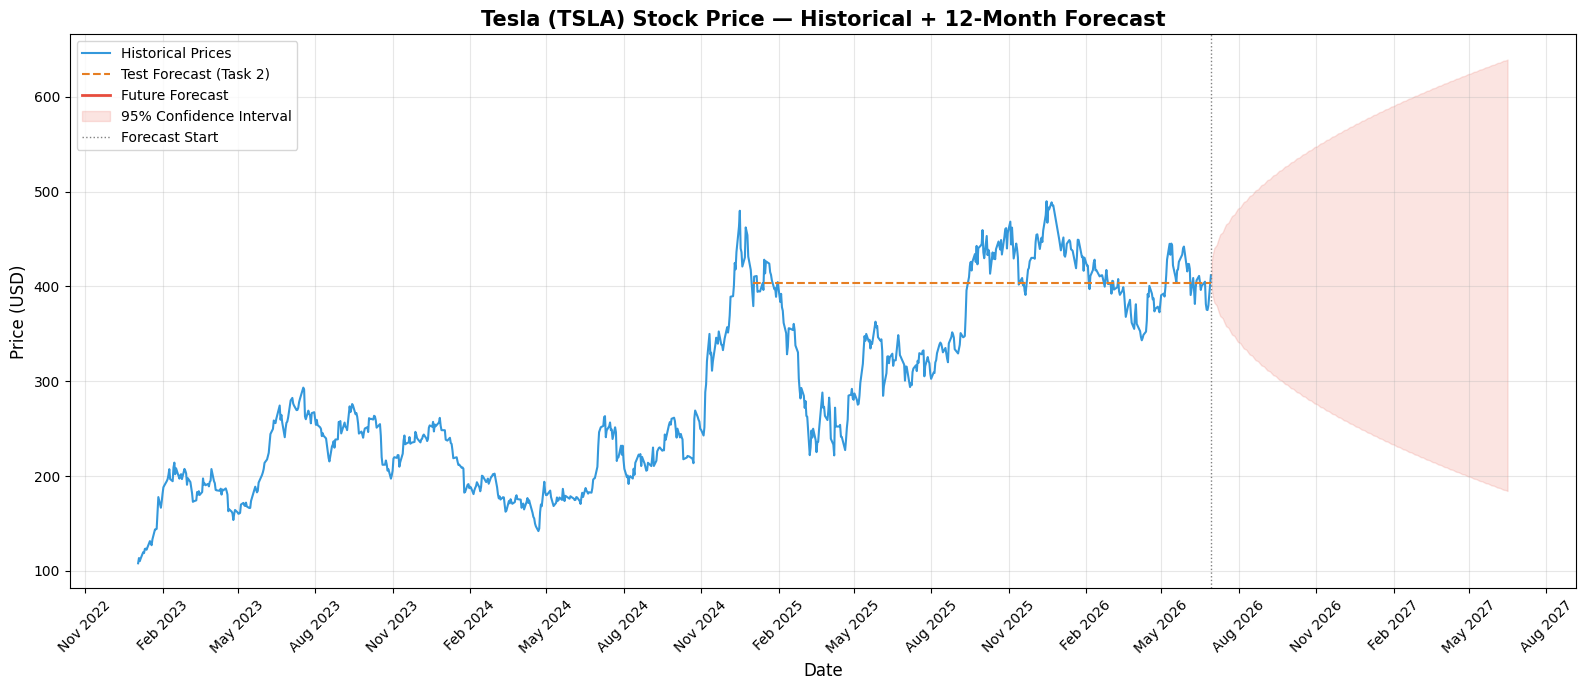

Plot saved to plots/task3_forecast_with_ci.png


In [9]:
fig, ax = plt.subplots(figsize=(16, 7))

recent_history = tsla_close[tsla_close.index >= "2023-01-01"]
ax.plot(recent_history.index, recent_history.values,
        color="#3498db", linewidth=1.5, label="Historical Prices")


ax.plot(test.index, test_forecast,
        color="#e67e22", linewidth=1.5, linestyle="--", label="Test Forecast (Task 2)")

# ── Plot the future forecast ──
ax.plot(forecast_df.index, forecast_df["Forecast"],
        color="#e74c3c", linewidth=2, label="Future Forecast")

# ── Shade the confidence interval ──
ax.fill_between(
    forecast_df.index,
    forecast_df["Lower_CI"],
    forecast_df["Upper_CI"],
    color="#e74c3c", alpha=0.15,
    label="95% Confidence Interval"
)

# ── Add a vertical line where the forecast begins ──
ax.axvline(x=last_date, color="gray", linestyle=":", linewidth=1, label="Forecast Start")

# ── Format the chart ──
ax.set_title("Tesla (TSLA) Stock Price — Historical + 12-Month Forecast", fontsize=15, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price (USD)", fontsize=12)
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plots/task3_forecast_with_ci.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to plots/task3_forecast_with_ci.png")


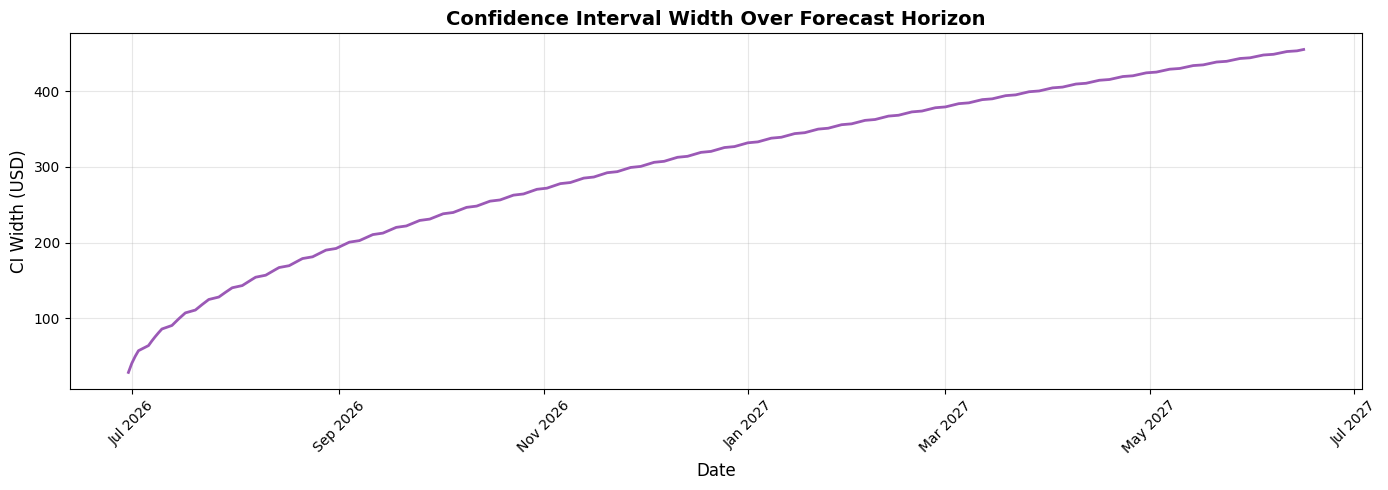

CI Width at 1 month:   $134.44
CI Width at 3 months:  $229.30
CI Width at 6 months:  $323.01
CI Width at 12 months: $455.00


In [10]:
# ── Calculate how the confidence interval width grows over time ──
forecast_df["CI_Width"] = forecast_df["Upper_CI"] - forecast_df["Lower_CI"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(forecast_df.index, forecast_df["CI_Width"], color="#9b59b6", linewidth=2)
ax.set_title("Confidence Interval Width Over Forecast Horizon", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("CI Width (USD)", fontsize=12)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plots/task3_ci_width.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Print key numbers ──
print(f"CI Width at 1 month:   ${forecast_df['CI_Width'].iloc[21]:.2f}")
print(f"CI Width at 3 months:  ${forecast_df['CI_Width'].iloc[63]:.2f}")
print(f"CI Width at 6 months:  ${forecast_df['CI_Width'].iloc[126]:.2f}")
print(f"CI Width at 12 months: ${forecast_df['CI_Width'].iloc[-1]:.2f}")


## 5. Trend Analysis

In [11]:
# ── Calculate key trend statistics ──
current_price = tsla_close.iloc[-1]
forecast_end_price = forecast_df["Forecast"].iloc[-1]
forecast_min = forecast_df["Forecast"].min()
forecast_max = forecast_df["Forecast"].max()
price_change = forecast_end_price - current_price
price_change_pct = (price_change / current_price) * 100

# ── Determine the overall trend direction ──
if price_change_pct > 5:
    trend = "UPWARD"
elif price_change_pct < -5:
    trend = "DOWNWARD"
else:
    trend = "STABLE"

# ── Monthly forecast summary ──
monthly_prices = forecast_df["Forecast"].resample("ME").last()

print("=" * 60)
print("             TREND ANALYSIS SUMMARY")
print("=" * 60)
print(f"  Current Price (last known):  ${current_price:.2f}")
print(f"  Forecast End Price:          ${forecast_end_price:.2f}")
print(f"  Predicted Change:            ${price_change:+.2f} ({price_change_pct:+.1f}%)")
print(f"  Forecast Range:              ${forecast_min:.2f} – ${forecast_max:.2f}")
print(f"  Overall Trend:               {trend}")
print("=" * 60)

print("\n Monthly Forecast Prices:")
for date, price in monthly_prices.items():
    print(f"   {date.strftime('%B %Y'):>20s}:  ${price:.2f}")

             TREND ANALYSIS SUMMARY
  Current Price (last known):  $411.84
  Forecast End Price:          $nan
  Predicted Change:            $+nan (+nan%)
  Forecast Range:              $nan – $nan
  Overall Trend:               STABLE

 Monthly Forecast Prices:
              June 2026:  $nan
              July 2026:  $nan
            August 2026:  $nan
         September 2026:  $nan
           October 2026:  $nan
          November 2026:  $nan
          December 2026:  $nan
           January 2027:  $nan
          February 2027:  $nan
             March 2027:  $nan
             April 2027:  $nan
               May 2027:  $nan
              June 2027:  $nan


## 6. Market Opportunities and Risks Assessment

In [12]:
# ── Calculate risk/opportunity metrics ──
upside_potential = forecast_df["Upper_CI"].iloc[-1] - current_price
downside_risk = current_price - forecast_df["Lower_CI"].iloc[-1]
max_upside_pct = (upside_potential / current_price) * 100
max_downside_pct = (downside_risk / current_price) * 100

# ── Forecast volatility (standard deviation of predicted prices) ──
forecast_volatility = forecast_df["Forecast"].pct_change().dropna().std() * np.sqrt(252) * 100

# ── Short-term vs long-term CI comparison ──
ci_width_1m = forecast_df["CI_Width"].iloc[21]
ci_width_12m = forecast_df["CI_Width"].iloc[-1]
ci_growth_factor = ci_width_12m / ci_width_1m

print("=" * 60)
print("       MARKET OPPORTUNITIES & RISKS")
print("=" * 60)

print("\n OPPORTUNITIES:")
print(f"   • Best-case scenario (upper CI):  ${forecast_df['Upper_CI'].iloc[-1]:.2f}")
print(f"   • Maximum upside potential:       +${upside_potential:.2f} ({max_upside_pct:+.1f}%)")
if price_change_pct > 0:
    print(f"   • Model predicts a POSITIVE trend of {price_change_pct:+.1f}%")

print("\n RISKS:")
print(f"   • Worst-case scenario (lower CI): ${forecast_df['Lower_CI'].iloc[-1]:.2f}")
print(f"   • Maximum downside risk:          -${downside_risk:.2f} ({max_downside_pct:.1f}%)")
print(f"   • Forecast volatility (annual):   {forecast_volatility:.1f}%")
if price_change_pct < 0:
    print(f"   • Model predicts a NEGATIVE trend of {price_change_pct:.1f}%")

print("\n UNCERTAINTY ASSESSMENT:")
print(f"   • CI width at 1 month:   ${ci_width_1m:.2f}")
print(f"   • CI width at 12 months: ${ci_width_12m:.2f}")
print(f"   • CI grows {ci_growth_factor:.1f}x from month 1 to month 12")
print(f"   • This means long-term forecasts are {ci_growth_factor:.1f}x less certain")
print("=" * 60)


       MARKET OPPORTUNITIES & RISKS

 OPPORTUNITIES:
   • Best-case scenario (upper CI):  $639.34
   • Maximum upside potential:       +$227.50 (+55.2%)

 RISKS:
   • Worst-case scenario (lower CI): $184.34
   • Maximum downside risk:          -$227.50 (55.2%)
   • Forecast volatility (annual):   nan%

 UNCERTAINTY ASSESSMENT:
   • CI width at 1 month:   $134.44
   • CI width at 12 months: $455.00
   • CI grows 3.4x from month 1 to month 12
   • This means long-term forecasts are 3.4x less certain


## 7. Forecast Reliability Assessment

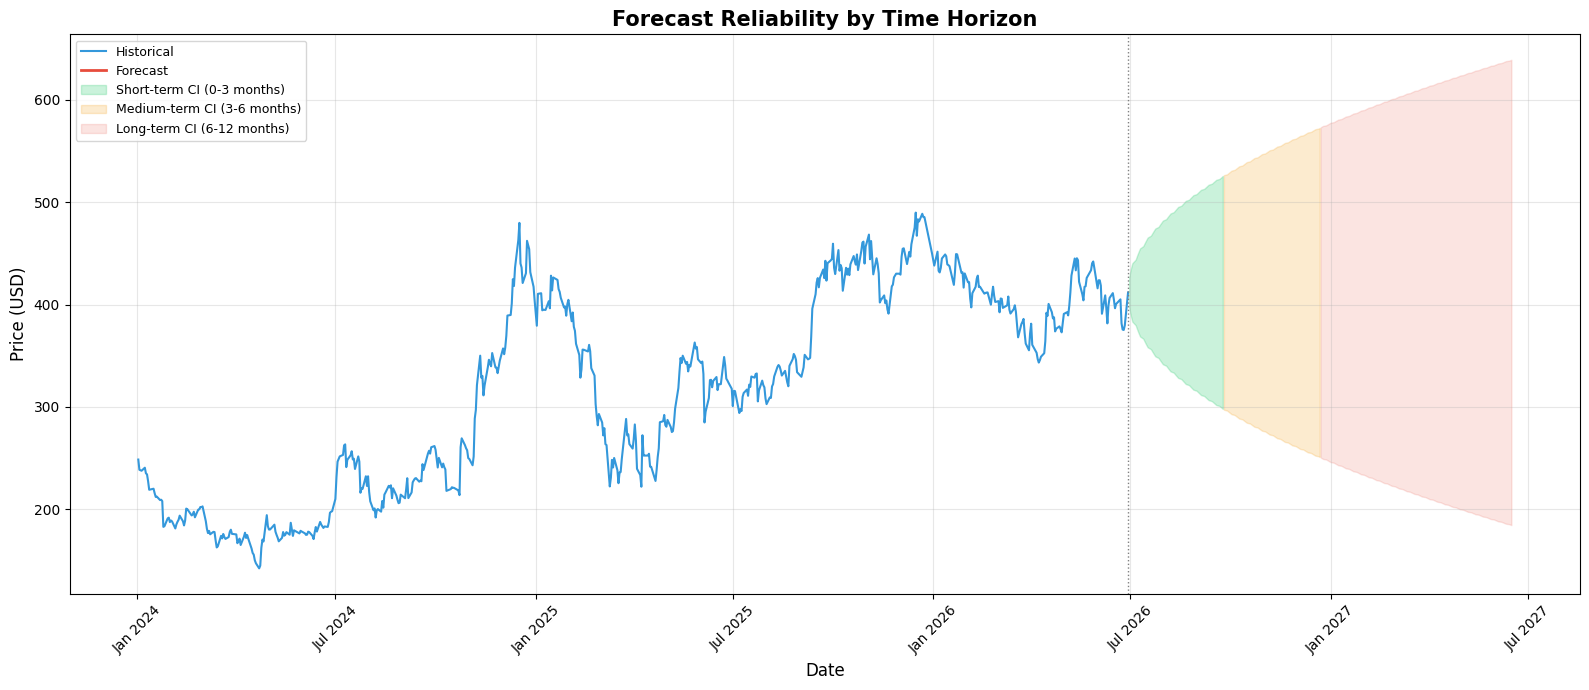

In [13]:
# ── Create a summary visualization: forecast with zones ──
fig, ax = plt.subplots(figsize=(16, 7))

# Historical prices (last year)
recent = tsla_close[tsla_close.index >= "2024-01-01"]
ax.plot(recent.index, recent.values, color="#3498db", linewidth=1.5, label="Historical")

# Forecast line
ax.plot(forecast_df.index, forecast_df["Forecast"], color="#e74c3c", linewidth=2, label="Forecast")


short = forecast_df.iloc[:63]
ax.fill_between(short.index, short["Lower_CI"], short["Upper_CI"],
                color="#2ecc71", alpha=0.25, label="Short-term CI (0-3 months)")

# Medium-term (3-6 months)
medium = forecast_df.iloc[63:126]
ax.fill_between(medium.index, medium["Lower_CI"], medium["Upper_CI"],
                color="#f39c12", alpha=0.20, label="Medium-term CI (3-6 months)")

# Long-term (6-12 months) — lightest shading, least reliable
long_term = forecast_df.iloc[126:]
ax.fill_between(long_term.index, long_term["Lower_CI"], long_term["Upper_CI"],
                color="#e74c3c", alpha=0.15, label="Long-term CI (6-12 months)")

ax.axvline(x=last_date, color="gray", linestyle=":", linewidth=1)

ax.set_title("Forecast Reliability by Time Horizon", fontsize=15, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price (USD)", fontsize=12)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plots/task3_reliability_zones.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# ── Save forecast results to CSV ──
forecast_df.to_csv("../data/task3_forecast_results.csv")
print("Forecast data saved to data/task3_forecast_results.csv")


print("TASK 3 COMPLETE — DELIVERABLES")
print("=" * 60)
print("  Forecast visualization:    plots/task3_forecast_with_ci.png")
print("  CI width analysis:         plots/task3_ci_width.png")
print("  Reliability zones:         plots/task3_reliability_zones.png")
print("  Forecast data (CSV):       data/task3_forecast_results.csv")
print("  Trend analysis:            Written in Section 8 above")
print("  Opportunities & risks:     Written in Section 8 above")
print("=" * 60)


Forecast data saved to data/task3_forecast_results.csv
TASK 3 COMPLETE — DELIVERABLES
  Forecast visualization:    plots/task3_forecast_with_ci.png
  CI width analysis:         plots/task3_ci_width.png
  Reliability zones:         plots/task3_reliability_zones.png
  Forecast data (CSV):       data/task3_forecast_results.csv
  Trend analysis:            Written in Section 8 above
  Opportunities & risks:     Written in Section 8 above
